# Required assignment 6.1: Implementing performance evaluation metrics

In this notebook, you’ll fit polynomials to three-dimensional data to determine which polynomial order provides the best fit. Since the data can’t be visualised directly, you’ll write functions to calculate performance metrics that help assess model accuracy.

In [1]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import pathlib as pl
import os
import pandas as pd

from kaggle.playground import df

## Metrics for model selection



In [2]:
#Set random seed for reproducibility
seed = 2022
np.random.seed(seed)

## Load the data

In [3]:
data = pd.read_csv('data/M6_Performance_Metrics_Data.csv')

In [7]:
data.shape

(100, 5)

In [4]:
print(data.head())

   Unnamed: 0        x1        x2        x3          y
0           0  0.382303 -1.596593  1.233776   4.935364
1           1  1.902436  1.579109 -0.341741  25.138660
2           2 -1.689244  1.298489 -1.472081  -4.786340
3           3 -1.510509  1.937616 -1.600244  -3.185759
4           4  1.621717  0.515558 -1.869644  19.712731


## Section 1: Split the data into training, validation and test sets.

### Prompt 1: Write a function that splits the data into training, validation and test sets.

The function should take the data frame and the percentage splits for training, validation and test as inputs and return three separate data frames – one for each set.

Hint:

- Select the `training` set with a fraction provided by the `data_split[0]`.

- To select the `validation` set, use `df.drop(training_index)` to exclude the training data and then rescale the validation fraction relative to the remaining rows.

- Once the training and validation rows are removed, the remaining rows are the test set.

In [5]:
###GRADED
def split_dataframe(df, data_split):
    """function to divide a dataframe into training, validation and test dataframes
    :param df: the full dataframe which is to be divided
    :param data_split: a list containing the fraction of the full dataframe for each
    of training, validation and test, in that order
    :return training, validation, test: dataframes for each of the sets"""
# YOUR CODE HERE
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)  # Shuffle the dataframe
    train_size = int(data_split[0] * len(df))
    val_size = int(data_split[1] * len(df))
    training = df.iloc[:train_size]
    validation = df.iloc[train_size:train_size + val_size]
    test = df.iloc[train_size + val_size:]
    return training, validation, test


### Prompt 2: Use your function to split the data set into three parts: 40 per cent for training, 30 per cent for validation and 30 per cent for testing.

In [6]:
###GRADED
training, validation, test = split_dataframe(data, [0.4, 0.3, 0.3])

print(len(training))
print(len(validation))
print(len(test))


40
30
30


## Section 2: Write metrics functions

### Prompt 3: Write functions to calculate the metrics you will use to evaluate your model’s performance.

- The mean absolute error (MAE):  
$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

- The average error (AE):
$$
\text{AE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)
$$

- The mean absolute percentage error (MAPE):
$$
\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100
$$

- The root mean squared error (RMSE):
$$
\text{RMSE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

- The total sum of squared errors (SSE):
$$
\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

In [8]:
##Write your code here ##
##GRADED CELL
def RMSE(predictions, test_y):
    """function to compute RMSE
    :param predictions: the predicted values
    :param test_y: the true values
    :return RMSE: the root mean squared error"""

    len_predictions = len(predictions)
    squared_errors = (predictions - test_y) ** 2
    mse = np.sum(squared_errors) / len_predictions
    rmse = np.sqrt(mse)
    return rmse

def mean_abs_error(predictions, test_y):
    """function to compute mean absolute error
    :param predictions: the predicted values
    :param test_y: the true values
    :return MAE: the mean absolute error"""
    len_predictions = len(predictions)
    absolute_errors = np.abs(predictions - test_y)
    mae = np.sum(absolute_errors) / len_predictions
    return mae

def average_error(predictions, test_y):
    """function to compute average error
    :param predictions: the predicted values
    :param test_y: the true values
    :return AE: the average error"""
    len_predictions = len(predictions)
    errors = predictions - test_y
    ae = np.sum(errors) / len_predictions
    return ae
def mean_abs_percent_error(predictions, test_y):
    """function to compute mean absolute percentage error
    :param predictions: the predicted values
    :param test_y: the true values
    :return MAPE: the mean absolute percentage error"""
    len_predictions = len(predictions)
    absolute_percentage_errors = np.abs((predictions - test_y) / test_y) * 100
    mape = np.sum(absolute_percentage_errors) / len_predictions
    return mape
def total_sum_squared_error(predictions, test_y):
    """function to compute total sum of squared errors
    :param predictions: the predicted values
    :param test_y: the true values
    :return SSE: the total sum of squared errors"""
    len_predictions = len(predictions)
    squared_errors = (predictions - test_y) ** 2
    sse = np.sum(squared_errors)
    return sse

## Section 3: Fit models to the training data and calculate performance metrics for the validation set.

For polynomials of order 1, 2, 3 and 4, use `fit_model` to fit each model. This function uses the scikit-learn polynomial regression.

### Prompt 4: Write functions to convert a data frame into `NumPy` arrays.

Scikit-learn functions require NumPy arrays as input. To prepare your data, write a function that converts a data frame with columns [x1, x2, x3, y] into two `NumPy` arrays: X and y. X should have the shape (N, D), where N is the number of samples and D is the number of features (three in this case). y should have the shape (N,).

In [10]:
###GRADED CELL
def convert_to_numpy(df):
    """function to convert to numpy
    :param df: the dataframe given
    :param X: convert to numpy array of shape (N, D)
    :param y: convert to numpy array of shape (N, )
    :return X,y: the numpy arrays"""

    X = df[['x1', 'x2', 'x3']].to_numpy()
    y = df['y'].to_numpy()
    return X, y


### Fitting the model for polynomials of order 1 to 6, inclusive

1. Fit a polynomial to the training data using the `fit_model` function.

2. Use the `model.predict(X)` function to get the model predictions on the validation set.

3. Store the model in a dictionary of models in which the keys indicate the order and the items are the models.

4. Store the predictions in a separate dictionary in which the keys indicate the order and the items are `NumPy` arrays of the predictions.

In [11]:
def fit_model(X, y, order):
    model = Pipeline([('poly', PolynomialFeatures(degree=order)),
                      ('linear', LinearRegression(fit_intercept=False))])
    model = model.fit(X, y)
    return model

## Section 4: Calculate performance metrics for each model.

Now let's calculate the performance metrics for each model.

### Prompt 5: Use your dictionary of predictions to calculate and record each metric – either by storing the results in a data frame or by plotting them on a graph.

1. Calculate each metric for the models using the functions you previously defined.

2. Store the results in a data frame with one row per model, or display them using a graph.

Hint:
- For computing `model_dict()`, iterate the different orders and compute `fit_model()`.

- For computing `predictions_dict(order)`, iterate the different orders and use the `model_dict(order).predict()` on `X_valid`.

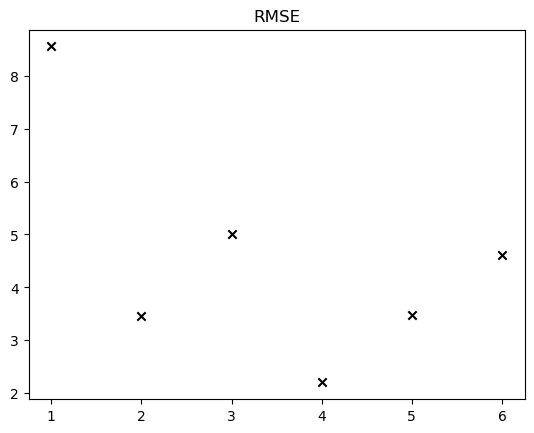

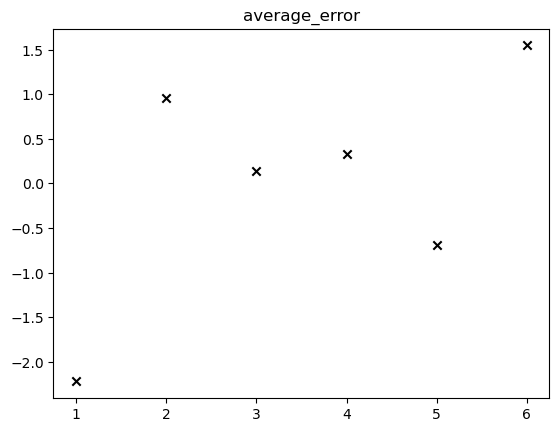

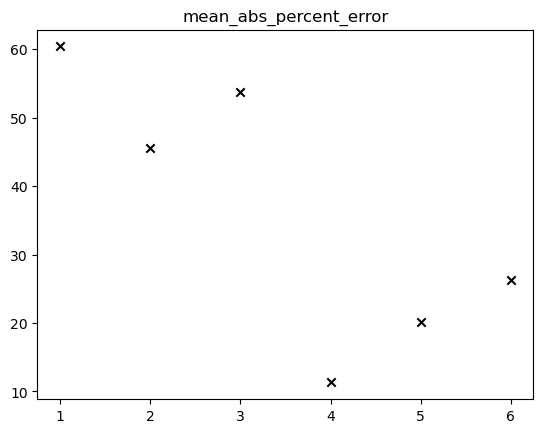

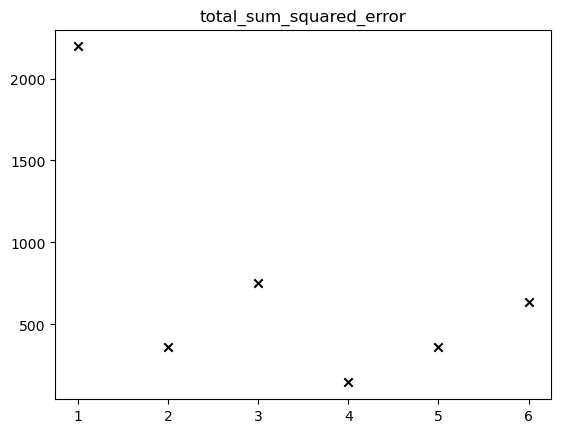

,Order,RMSE,AE,MAPE,SSE
0,1,8.554846,-2.218626,60.410511,2195.561711
1,2,3.466130,0.954247,45.648688,360.421617
2,3,5.002773,0.144554,53.731942,750.832172
3,4,2.201510,0.333394,11.313623,145.399383
4,5,3.482363,-0.693297,20.219939,363.805497
5,6,4.615994,1.546379,26.243000,639.222018


In [12]:
###GRADED CELL
#Initialise dictionaries to store the models and predictions
models_dict = {}
predictions_dict = {}

#Convert the training and validation data to NumPy arrays
X_train, y_train = convert_to_numpy(training)
X_valid, y_valid = convert_to_numpy(validation)

methods = [RMSE, average_error, mean_abs_percent_error, total_sum_squared_error]
method_names = ["RMSE", "average_error", "mean_abs_percent_error", "total_sum_squared_error"]
import matplotlib.pyplot as plt

#Fit the models and store predictions for each order
# YOUR CODE HERE
for order in range(1, 7):
    model = fit_model(X_train, y_train, order)
    models_dict[order] = model
    predictions_dict[order] = model.predict(X_valid)

#Now you can plot the metrics
for i, method in enumerate(methods):
    fig = plt.figure()
    for order in [1, 2, 3, 4, 5, 6]:
        res = method(predictions_dict[order], y_valid)
        plt.scatter(order, res, marker='x', color='k')
    plt.title(method_names[i])
    plt.show()

results = []
for order in range(1,7):
    preds = predictions_dict[order]
    results.append({
        "Order": order,
        "RMSE": RMSE(preds, y_valid),
        "AE": average_error(preds, y_valid),
        "MAPE": mean_abs_percent_error(preds, y_valid),
        "SSE": total_sum_squared_error(preds, y_valid),
    })
pd.DataFrame(results)

## Section 5: Use the test set to evaluate the performance of your selected model.

### Prompt 6: For your selected model, calculate the RMSE, AE and MAPE of the test data.

HINT:

- Compute the `RMSE()`, `average_error()` and `mean_abs_percent_error()` for the model of order 4.

- Use `convert_to_numpy()` on the test data set.

In [13]:
###GRADED CELL
# YOUR CODE HERE
# Convert test data to numpy arrays
X_test, y_test = convert_to_numpy(test)

# Get the best model (order 4 based on validation results)
best_model = models_dict[4]

# Make predictions on test set
y_new = best_model.predict(X_test)

# Calculate metrics
rmse_result = RMSE(y_new, y_test)
avg_error_result = average_error(y_new, y_test)
mape_result = mean_abs_percent_error(y_new, y_test)

print(rmse_result)
print(avg_error_result)
print(mape_result)

2.0761617883109196
-0.6222000542788314
43.62862507822976
